# Imports 

In [18]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import plotly.express as px

# Loading and previewing 

In [19]:
df = pd.read_csv('../data/cleaned/lagos_real_estate_market_data_cleaned.csv')
df.head()

,type,kind,price,title,location,beds,baths,agent,contact,listing_url,district
0,For Rent,Apartment,2.000000e+07,4 Units of 3 Bedroom Apartments in Lekki phase 1,Lekki Phase 1,3.0,3.0,Chinenye,+234 816 911 2079,https://cwlagos.com/property/4-units-of-3-bedr...,Lekki
1,For Sale,Detached Duplex,1.500000e+09,Luxury 5 Bedroom Fully Detached House in Lekki...,Lekki Phase 1,5.0,5.0,Chinenye,+234 816 911 2079,https://cwlagos.com/property/luxury-5-bedroom-...,Lekki
2,For Rent,Apartment,4.500000e+07,Furnished 3 Bedroom Apartment in Ikoyi,Banana Island,3.0,3.0,Adaeze,+234 816 631 5298,https://cwlagos.com/property/furnished-3-bedro...,Ikoyi
3,For Rent,Apartment,8.940853e+07,Luxury 3-Bedroom Apartment in Ikoyi,Banana Island,3.0,3.0,Adaeze,+234 816 631 5298,https://cwlagos.com/property/luxury-3-bedroom-...,Ikoyi
4,For Rent,Commercial,3.000000e+07,4 Bedroom Apartment for Commercial Use in VI,Victoria Island,0.0,0.0,Nadi,+2349062511345,https://cwlagos.com/property/4-bedroom-apartme...,Victoria Island


In [20]:
df.columns.to_frame().T

,type,kind,price,title,location,beds,baths,agent,contact,listing_url,district
0,type,kind,price,title,location,beds,baths,agent,contact,listing_url,district


In [21]:
# from the features we have we can , we can start to think throught he insighth we can find from this cleaned data
"""
first I'll explore the market overview and pricing analysis to try to understand things like
1. What does the overall price distribution of Lagos housing listings look like?


2. What is the typical (median) price range for properties in Lagos?


3. How are listings distributed across low-, mid-, and high-price segments?


4. How does price vary with number of bedrooms?


"""

"\nfirst I'll explore the market overview and pricing analysis to try to understand things like\n1. What does the overall price distribution of Lagos housing listings look like?\n\n\n2. What is the typical (median) price range for properties in Lagos?\n\n\n3. How are listings distributed across low-, mid-, and high-price segments?\n\n\n4. How does price vary with number of bedrooms?\n\n\n"

# Market Overview and Pricing

In [22]:
df['price'].describe().to_frame().T

,count,mean,std,min,25%,50%,75%,max
price,653.0,4.379179e+08,1.110910e+09,150000.0,25000000.0,120000000.0,450000000.0,1.500000e+10


In [23]:
df.dtypes

type               str
kind               str
price          float64
title              str
location           str
beds           float64
baths          float64
agent              str
contact            str
listing_url        str
district           str
dtype: object

In [24]:
df['price'] = df['price'].astype(float)

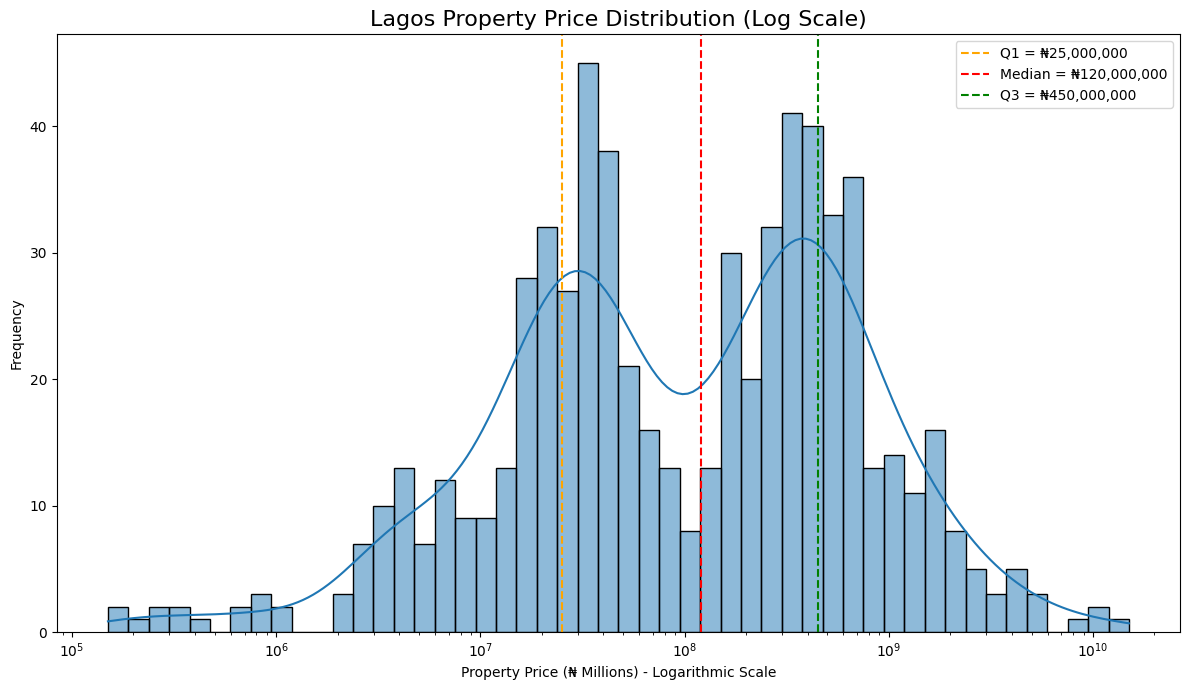

In [25]:
median_price = df['price'].median()
q1_price = df['price'].quantile(0.25)
q3_price = df['price'].quantile(0.75)

plt.figure(figsize=(12, 7))
sns.histplot(data=df, x='price', bins=50, kde=True, log_scale=True)
plt.axvline(q1_price, color='orange', linestyle='--', label=f'Q1 = ₦{q1_price:,.0f}')
plt.axvline(median_price, color='red', linestyle='--', label=f'Median = ₦{median_price:,.0f}')
plt.axvline(q3_price, color='green', linestyle='--', label=f'Q3 = ₦{q3_price:,.0f}')
plt.title('Lagos Property Price Distribution (Log Scale)', fontsize=16)
plt.xlabel('Property Price (₦ Millions) - Logarithmic Scale')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
""" 
We see that the house prices in lagos are slightly skewed to the right, there are very little houses at the 
lower end of the price spectrum 
The price distrbution almost follows a guassiona dist, but for the dip in the median price, which is around 120m. 


"""

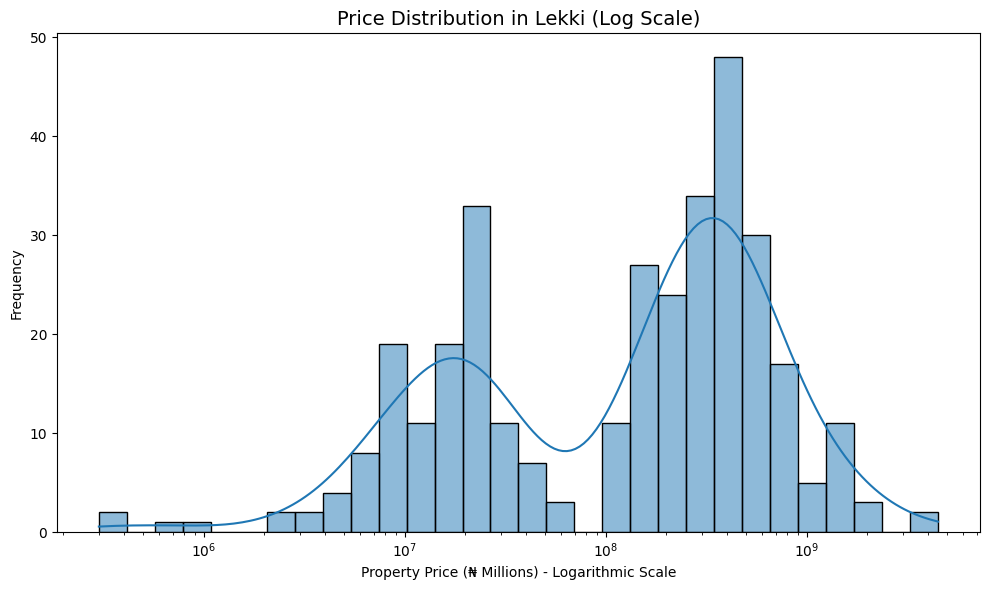

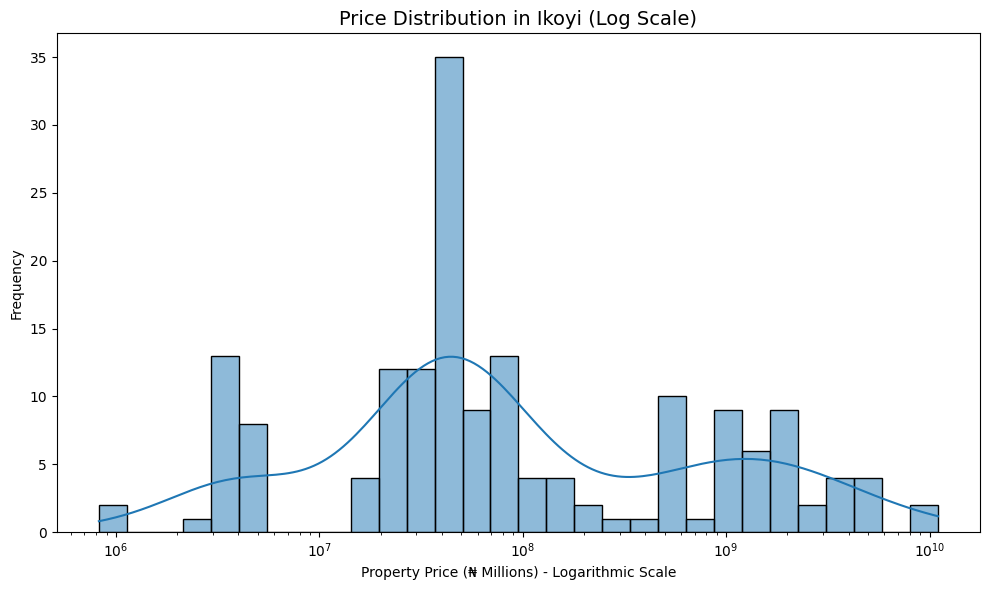

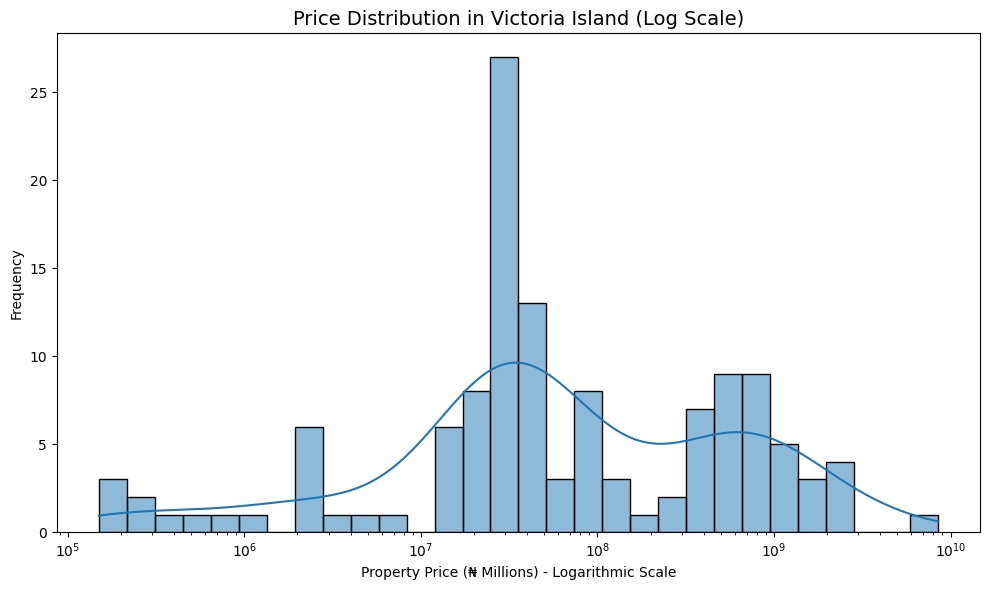

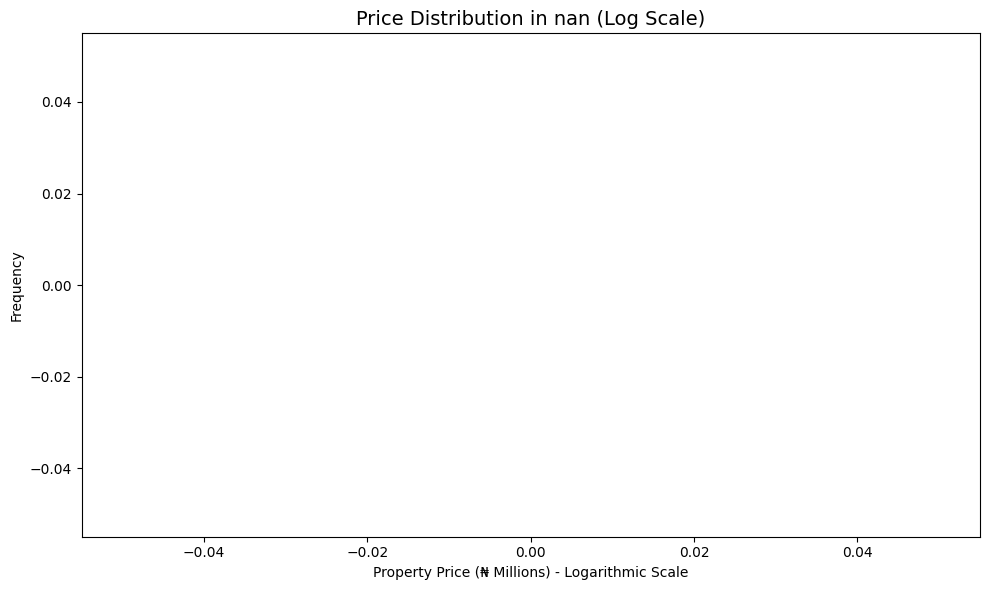

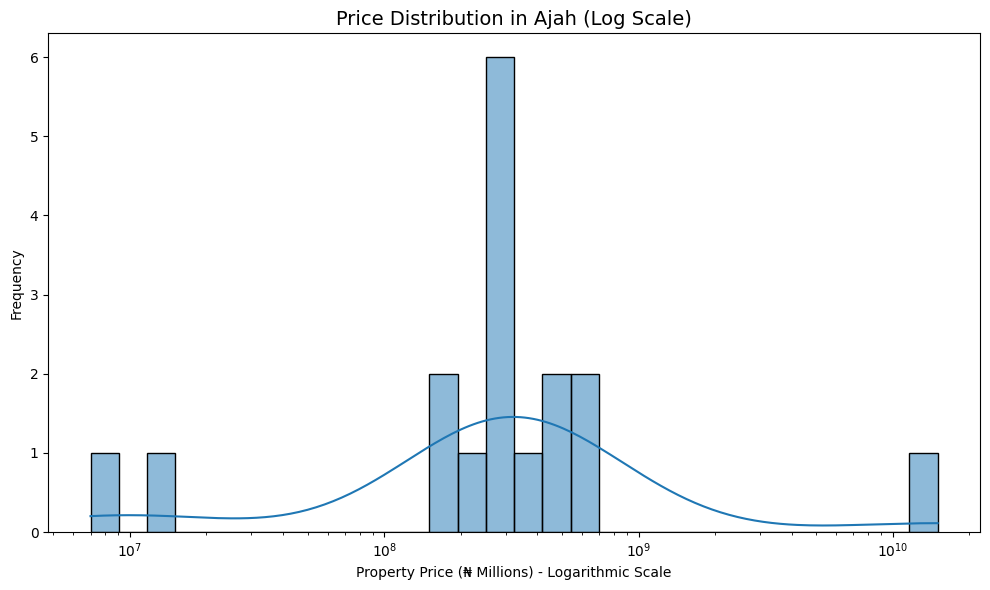

In [ ]:
# relationship between price and district
for district in df['district'].unique():
    district_data = df[df['district'] == district]
    plt.figure(figsize=(10, 6))
    sns.histplot(district_data['price'], bins=30, kde=True, log_scale=True)
    plt.title(f'Price Distribution in {district} (Log Scale)', fontsize=14)
    plt.xlabel('Property Price (₦ Millions) - Logarithmic Scale')
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()